<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/CuoiKy_car_price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

#  CẤU TRÚC BÀI :

- Bài toán: Dự đoán giá xe (price)
- Loại: Regression
- Mô hình: Linear Regression (implement bằng Gradient Descent)
# PIPELINE HỆ THỐNG:
1. Đọc dữ liệu
2. EDA + Data Cleaning
3. Feature Engineering
4. Train/Test Split
5. Chuẩn hóa dữ liệu
6. Xây dựng mô hình Gradient Descent
7. Huấn luyện (Training)
8. Đánh giá (MAE, MSE, RMSE, R2)
9. Visualization (Loss Curve)
10. Phân tích kết quả (Overfitting / Underfitting)

# BƯỚC 1.Đọc dữ liệu (file csv từ github)


In [ ]:
url = "https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/main/CarPrice_Assignment.csv"
df = pd.read_csv(url)


rows, cols = df.shape

print("Số dòng:", rows)
print("Số cột:", cols)
df.head()

Số dòng: 205
Số cột: 26


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# Tổng quan dữ liệu
Dataset ban đầu gồm:
- 205 dòng (mỗi dòng tương ứng với một mẫu xe)
- 26 cột (mỗi cột là một đặc trưng mô tả.)

# Target : Price

Học có giám sát Supervised Learning – Regression (predict giá xe)

# 2. Phân loại Feature
**Numeric (dùng trực tiếp cho Linear Regression)**

- wheelbase, carlength,
- carwidth, carheight
- curbweight
- enginesize
- boreratio, stroke
- compressionratio
- horsepower
- peakrpm
- citympg, highwaympg

**Categorical ( encode cho MLP)**
- fueltype
- aspiration
- doornumber
- carbody
- drivewheel
- enginelocation
- enginetype
- cylindernumber
- fuelsystem

# Bước 2 : EDA VÀ DATA LEARNING


# 2.1 Kiểm tra dữ liệu
- Kiểm tra giá trị thiếu
- Kiểm tra giá trị trùng lặp
- Kiểm tra kiểu dữ liệu
- Kiểm tra số lượng giá trị duy nhất của mỗi cột
- Kiểm tra thống kê của tập dữ liệu
- Kiểm tra các danh mục khác nhau có trong các cột phân loại khác nhau

In [ ]:
# KIỂM TRA DỮ LIỆU THIẾU
df.isnull().sum()
# KIỂM TRA DỮ LIỆU TRÙNG
df.duplicated().sum()



# 2.1.1 Kiểm tra giá trị thiếu(missing)

In [ ]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


**==> Nhận xét: không có giá trị null**

# 2.1.2 Kiểm tra giá trị trùng lắp (duplicate)

In [ ]:
df.duplicated().sum()

np.int64(0)

**==> Nhận xét : không có dòng nào duplicate**

# Top feature tương quan với giá

In [ ]:
corr_target = corr['price'].sort_values(ascending=False)
print(corr_target)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


# ==> có 3 feature tương quan với giá nhất
- enginesize          0.874145
- curbweight          0.835305
- horsepower          0.808139

# Insight tuyến tính
- enginesize vs price

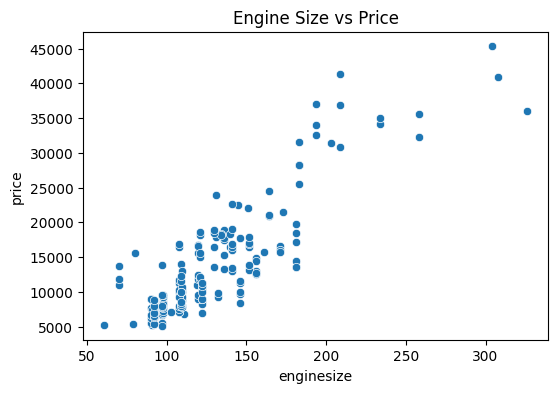

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='enginesize', y='price', data=df)
plt.title("Engine Size vs Price")
plt.show()

- horsepower vs price

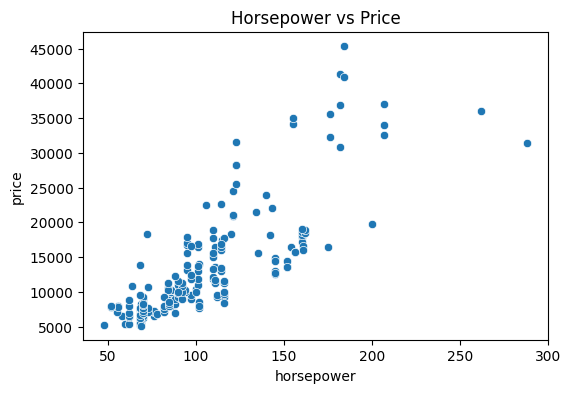

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='horsepower', y='price', data=df)
plt.title("Horsepower vs Price")
plt.show()

- curbweight vs price

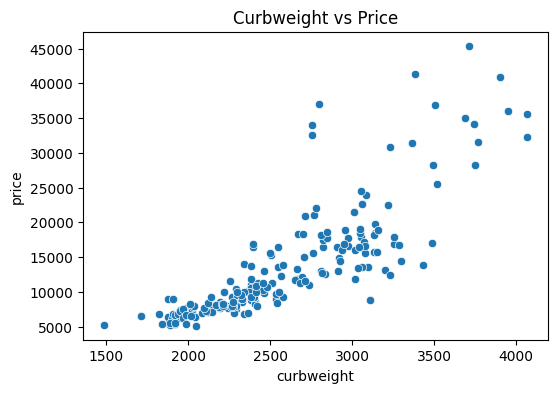

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='curbweight', y='price', data=df)
plt.title("Curbweight vs Price")
plt.show()

- MPG (quan hệ nghich)

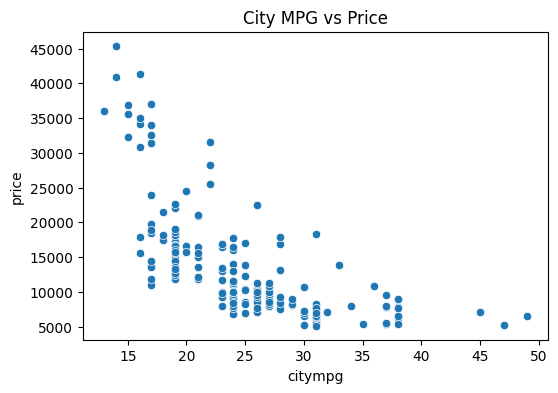

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='citympg', y='price', data=df)
plt.title("City MPG vs Price")
plt.show()

# Phân tích catagory (MLP)
- Brand vs Price

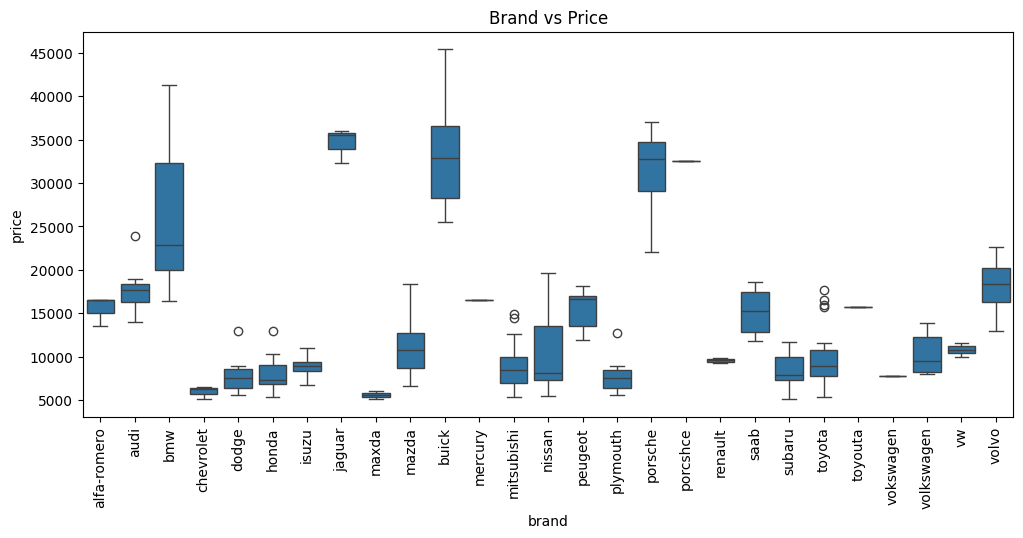

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='brand', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Brand vs Price")
plt.show()

- Carbody vs Price

# 3.3 Kiểm tra kiểu dữ liệu

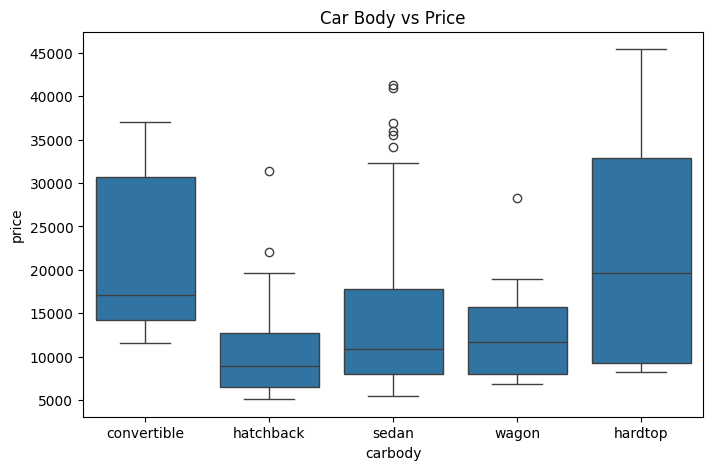

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='carbody', y='price', data=df)
plt.title("Car Body vs Price")
plt.show()

In [ ]:
df.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


# 3.4 Kiểm tra số lượng giá trị duy nhất của mỗi cột

In [ ]:
df.nunique()

,0
car_ID,205
symboling,6
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
wheelbase,53


# 3.5 Kiểm tra thống kê của tập dữ liệu

In [ ]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


# ==> Nhận xét:
**1. Sự đa dạng của xe hơi :**
- Bộ dữ liệu bao gồm: 205 mẫu xe hơi, mỗi mẫu đều có những đặc điểm riêng biệt.

- *Sizes, weights, and engine capacities* :khác nhau giữa các xe.

**2.Khoảng Price:**
- Min Price: 5.118 đô la
- Max Price: 45.400 đô la
- Ave Price: 13.276 đô la.

**3. Sự đa dạng của động cơ :**
- Các động cơ khác nhau về đường kính xi lanh (*boreratio*) và chiều dài hành trình piston (*stroke)*.
- Xếp hạng rủi ro (*symboling*): giá trị -2 đến 3.

**4. Phân bố dữ liệu:**
- Các đặc điểm : arwidth, curbweight, enginesize: có sự biến đổi đáng kể.

+ *compressionratio* và *horsepower*: có các giá trị ngoại lệ

# 3.6 Kiểm tra các danh mục khác nhau có trong các cột phân loại khác nhau.

In [ ]:
categorical_columns = ['fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype',
    'cylindernumber',
    'fuelsystem'
]

for col in categorical_columns:

    print(f"Category in {col} is : {df[col].unique()}")

Category in fueltype is : ['gas' 'diesel']
Category in aspiration is : ['std' 'turbo']
Category in doornumber is : ['two' 'four']
Category in carbody is : ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
Category in drivewheel is : ['rwd' 'fwd' '4wd']
Category in enginelocation is : ['front' 'rear']
Category in enginetype is : ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
Category in cylindernumber is : ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
Category in fuelsystem is : ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


# 4. EDA ( Phân tích dữ liệu)

# 4.1 Phân bố đặc điểm # Numerical Features

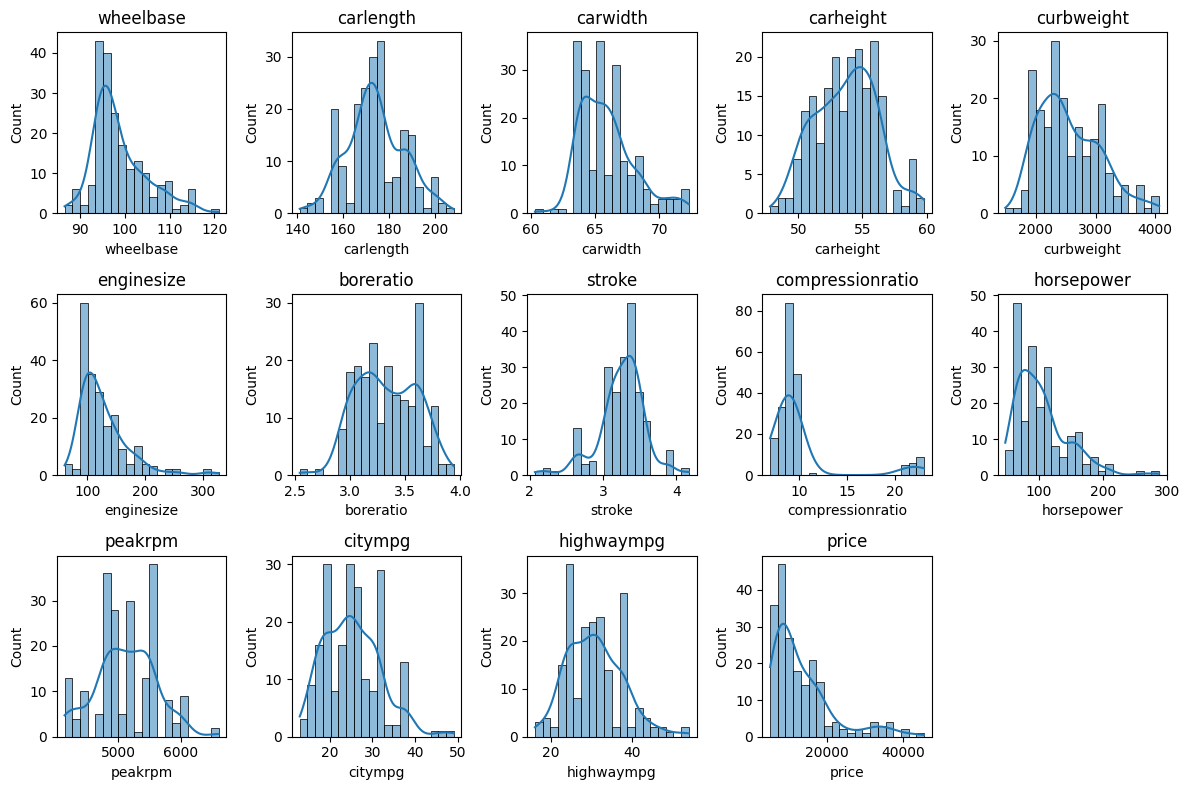

In [ ]:
numerical_features = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
                      'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
                      'peakrpm', 'citympg', 'highwaympg', 'price']

plt.figure(figsize=(12, 8))
for feature in numerical_features:
    plt.subplot(3, 5, numerical_features.index(feature) + 1)
    sns.histplot(data=df[feature], bins=20, kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

# 4.2 Phân tích Price

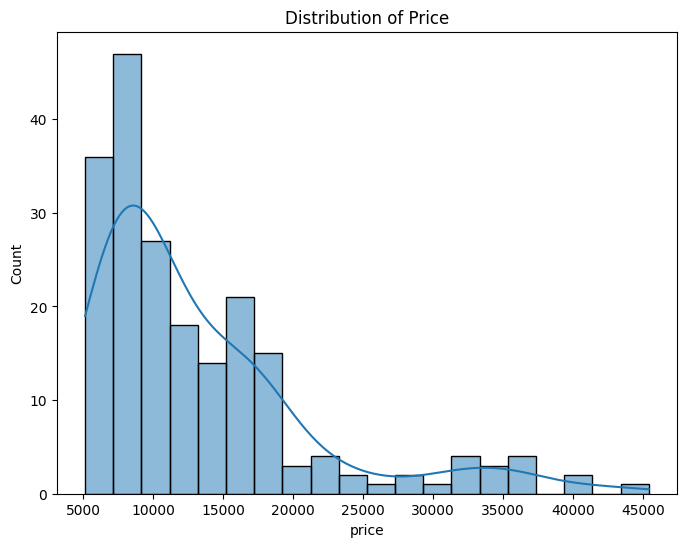

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df['price'], bins=20, kde=True)
plt.title('Distribution of Price')
plt.show()

# 4.3 Xác định Danh sách các cột phân loại cần phân tích

/tmp/ipykernel_2463/57535268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
/tmp/ipykernel_2463/57535268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
/tmp/ipykernel_2463/57535268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
/tmp/ipykernel_2463/57535268.py:10: FutureWarning: 

Passing `palette` without assign

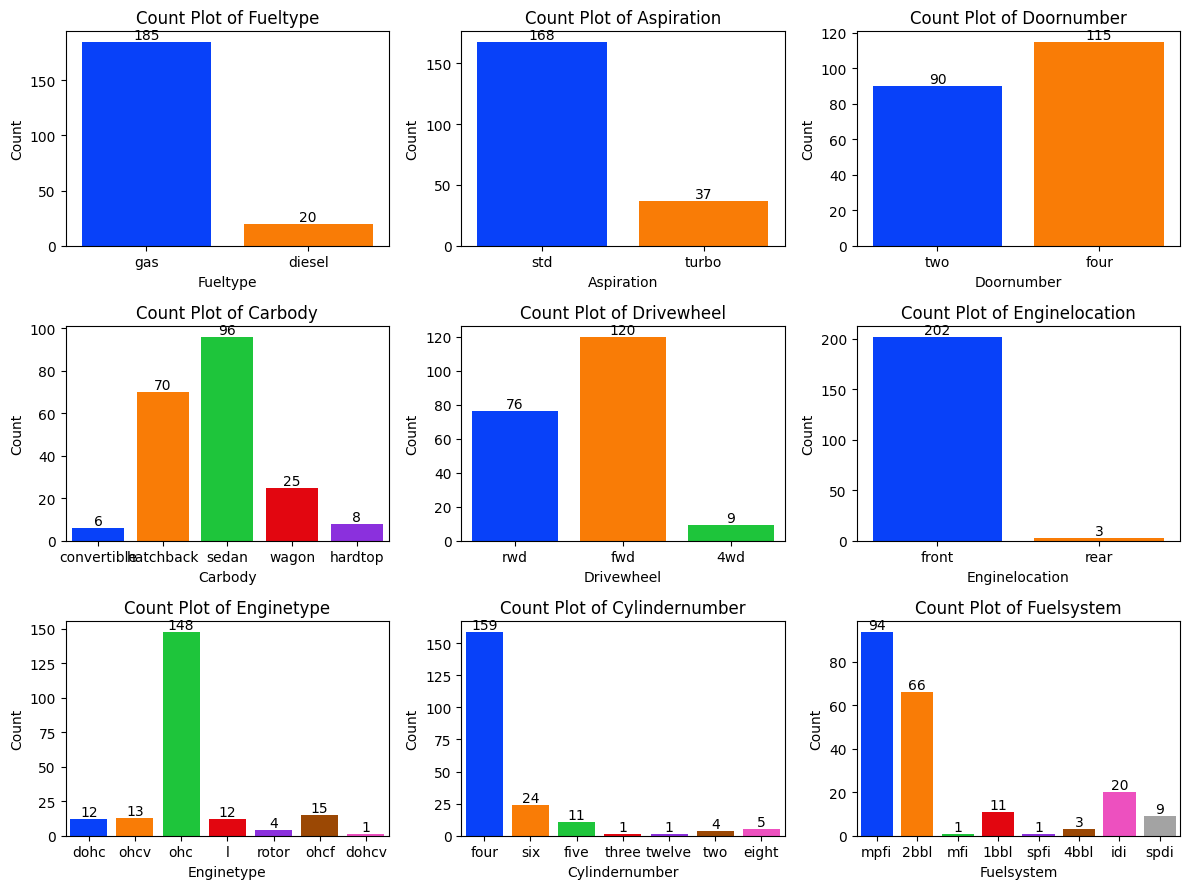

In [ ]:
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 9))
axes = axes.ravel()  # Flatten the 2D array of axes

# Loop through each categorical column
for i, column in enumerate(categorical_columns):
    sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=10)
    axes[i].set_title(f'Count Plot of {column.capitalize()}')
    axes[i].set_xlabel(column.capitalize())
    axes[i].set_ylabel('Count')

# Adjust layout and show plots
plt.tight_layout()
plt.show()

- Gas: 90% (185) - Giá rẻ --> trung cấp
- Diesel : 10% (20) -> giá cao
==> Gas chiếm đa số ( link kiện phổ biến cho toyota)

# 4.4 Số lượng mẫu xe hàng đầu cần vẽ biểu đồ

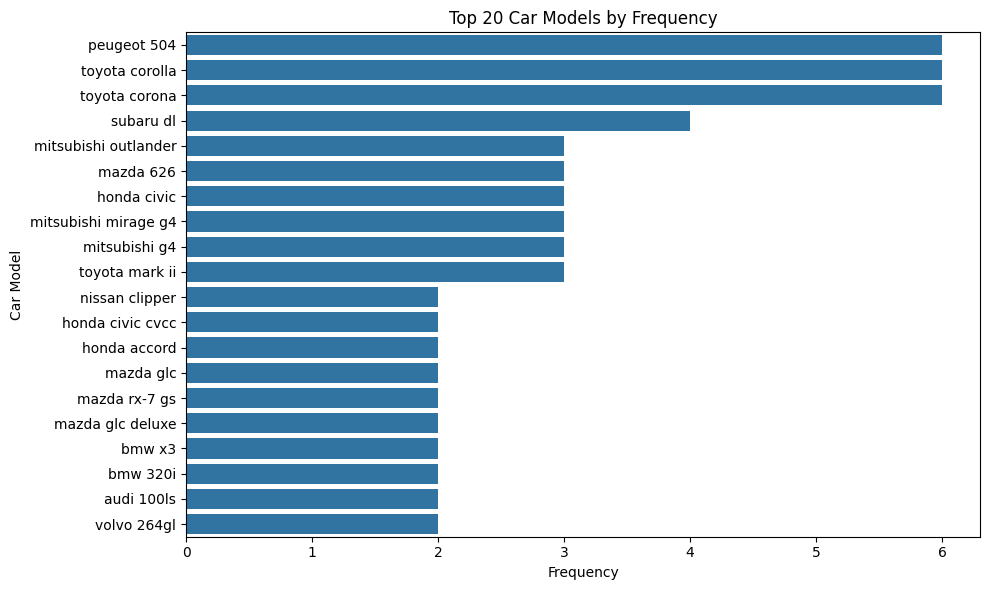

In [ ]:
n = 20  # Number of top car models to plot
top_car_models = df['CarName'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

# 4.5 # Tính giá trung bình cho từng mẫu xe

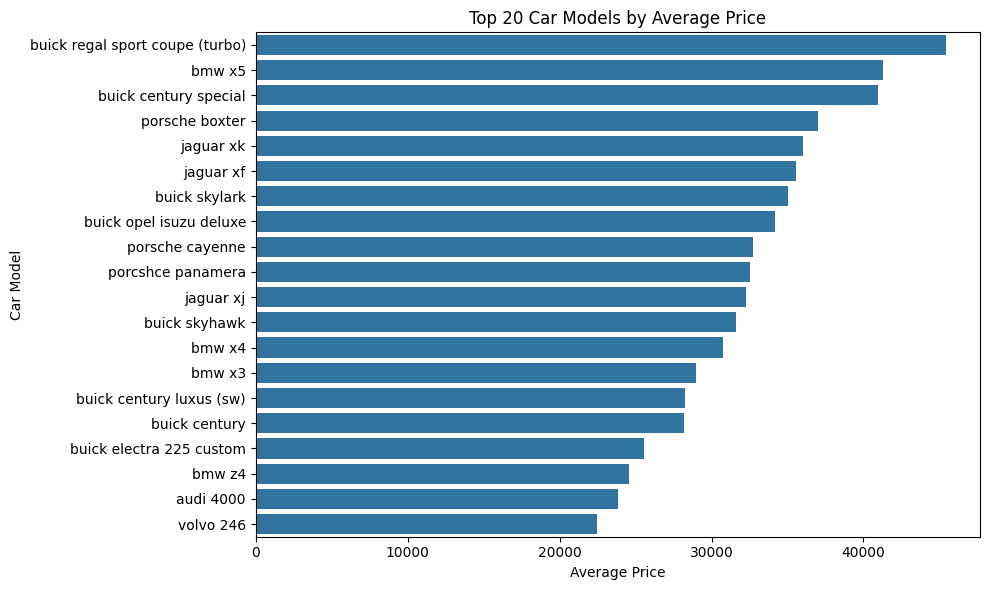

In [ ]:
# Calculate average price for each car model
avg_prices_by_car = df.groupby('CarName')['price'].mean().sort_values(ascending=False)

# Plot top N car models by average price
n = 20  # Number of top car models to plot
top_car_models = avg_prices_by_car.head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

# 4.6
# Tính năng phân loại so với giá cả

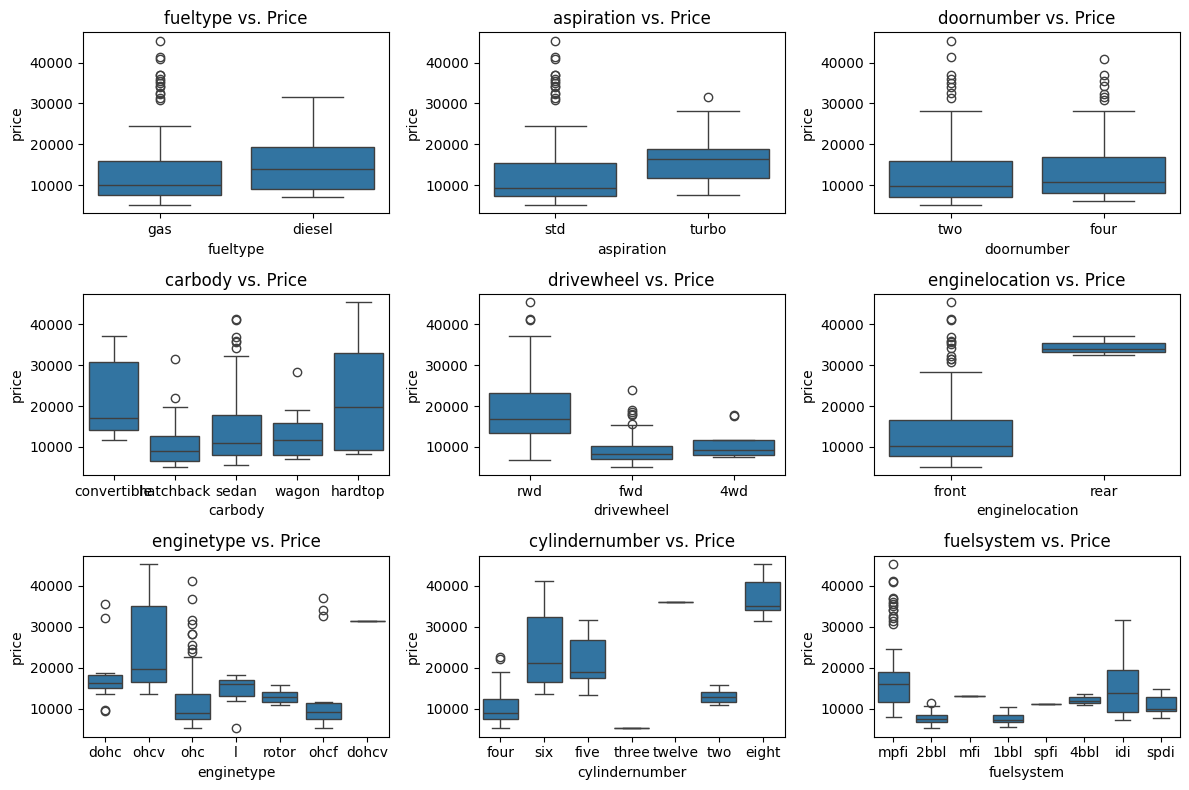

In [ ]:
# Categorical Feature vs. Price
plt.figure(figsize=(12, 8))
for feature in categorical_columns:
    plt.subplot(3, 3, categorical_columns.index(feature) + 1)
    sns.boxplot(data=df, x=feature, y='price')
    plt.title(f'{feature} vs. Price')
plt.tight_layout()
plt.show()

# 4.7 # Phân tích tương quan

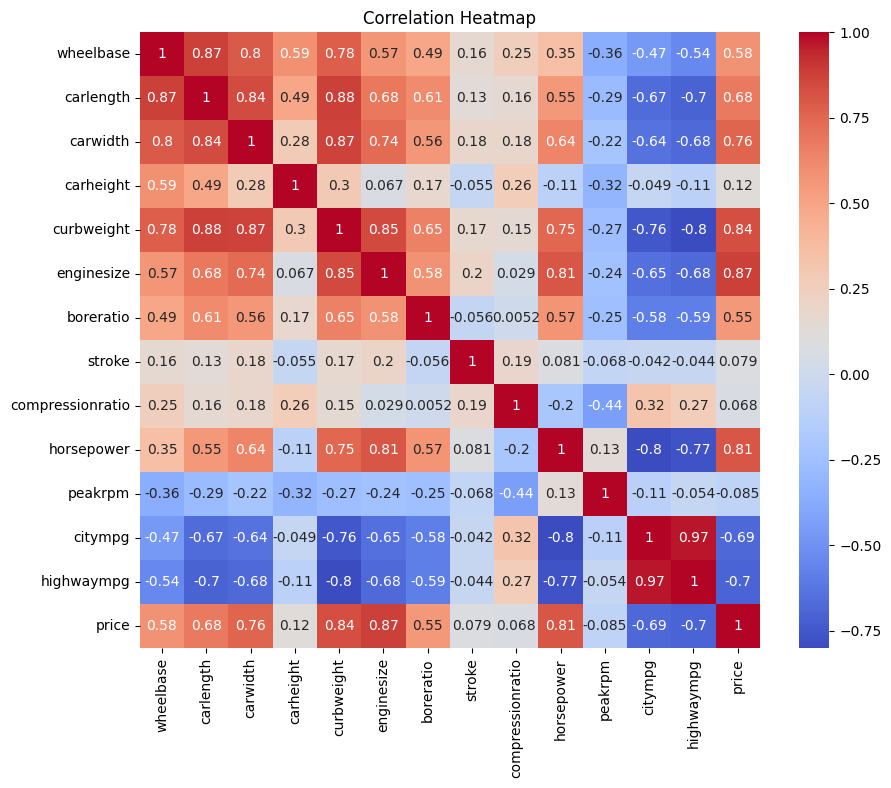

In [ ]:
# Correlation Analysis
numerical_features = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
                      'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
                      'peakrpm', 'citympg', 'highwaympg', 'price']

correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Nhận xét chung
**1. Thông tin tổng quan về dữ liệu**
- - Quy mô: 205 dòng và 26 cột dữ liệu.
Chất lượng: Dữ liệu sạch, không có giá trị trống (null) và không có dữ liệu trùng lặp.
- Thương hiệu phổ biến: Toyota là hãng xe xuất hiện nhiều nhất.

**2. Thống kê về giá xe (Price)**
- Giá trung bình: $13,276.

- Khoảng giá: Thấp nhất là $5,118 và  cao nhất $45,400.

**3. Nhiên liệu và Động cơ (Fuel & Engine)**
- Loại nhiên liệu:

-- Xăng (Gas): Chiếm đa số (~90%), giá thành rẻ hơn.

---Dầu (Diesel): Chỉ chiếm khoảng 10% nhưng có giá trung bình cao hơn xe xăng.

- Hệ thống nạp: 82% là xe hút khí tự nhiên (Standard), giá rẻ hơn so với 18% xe có bộ tăng áp (Turbo).

- Loại động cơ: Phổ biến nhất là loại "ohc" vì giá thành thấp.
- Số xi-lanh: Phần lớn người dùng chọn loại 4 xi-lanh. Tuy nhiên, giá xe có xu hướng tăng tỷ lệ thuận với số lượng xi-lanh.

**4. Kiểu dáng và Thiết kế (Body & Design)**
- Loại xe: Người dùng thích dòng Sedan nhất. Các dòng như Convertible (mui trần) và Hardtop có giá cao hơn nhưng vẫn được ưa chuộng.
- Số cửa: 56% chọn xe 4 cửa, 46% chọn xe 2 cửa. Các dòng xe thể thao có mức giá trung bình tương đương các dòng khác.
- Hệ dẫn động: Đa số chọn cầu trước (fwd) để tối ưu chi phí.

**5. Các yếu tố ảnh hưởng đến giá thành**
- Yếu tố tác động mạnh:  Kích thước động cơ (Engine size), chiều dài cơ sở (Wheelbase), chiều dài và chiều rộng của xe đều khiến giá xe tăng lên.
- Yếu tố không tác động: Chiều cao của xe không ảnh hưởng đáng kể đến giá bán.


# 5. Tiền xử lý dữ liệu

In [ ]:
# Extract brand and model from CarName
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])
df['model'] = df['CarName'].apply(lambda x: ' '.join(x.split(' ')[1:]))

# Define categorical and numerical columns
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'model']
numerical_columns = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
                     'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
                     'peakrpm', 'citympg', 'highwaympg']

# Encoding categorical variables
label_encoder = LabelEncoder()
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Feature engineering
df['power_to_weight_ratio'] = df['horsepower'] / df['curbweight']
for column in numerical_columns:
    df[f'{column}_squared'] = df[column] ** 2
df['log_enginesize'] = np.log(df['enginesize'] + 1)

# Feature scaling
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])